## Experiemtal Result

In [ ]:
import os

import json
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
SIMRESULT = "simulate/sim_result/"

In [45]:
MAP = {
    "Phase0_vs_Phase0": "v0_random_vs_v0_random",
    "Phase0_vs_Phase1": "v0_random_vs_v1_opening",
    "Phase1_vs_Phase2": "v1_opening_vs_v2_search",
    "Phase2_vs_Phase3_v2": "v2_search_vs_v3_move_ordering",
    "Phase2_vs_Phase3_v1": "v2_search_vs_v4_time_control",
    "Phase3_vs_Phase4_v2": "v3_move_ordering_vs_v4_time_control",
    "Phase3_vs_aspiration": "v4_vs_v4+aspiration",
    "Phase3_vs_skip_move": "v4_vs_v4+skip_move",
    "Phase3_vs_extension": "v4_vs_v4+extension",
    "Phase3_vs_pvs": "v4_vs_v4+pvs"
}

In [ ]:
def change_run_name(path):
    
    with open(path, mode='r') as f:
        config = json.load(f)
    print(config)

    config['run_name'] = MAP[config['run_name']]

    with open(path, mode='w') as f:
        json.dump(config, f, indent=4)

change_run_name("./config/exp_configs/phase/Phase2_vs_Phase3_v2.json")

{'run_name': 'Phase2_vs_Phase3_v2', 'n_episodes': 100, 'p0_policy': {'type': 'SearchPolicy', 'search_engine': {'type': 'AB_SearchEngine'}, 'config_schedule': {'evaluate': 'evaluate_bad_moves', 'move_ordering': None, 'depth': 30, 'use_iterative_deepening': True, 'deterministic': False, 'use_time_control': True, 'budget_manager': {'type': 'BudgetManager_default', 'w_scheduler': {'type': 'ConstantScheduler', 'v': 2.0}}, 'use_pvs': False, 'use_aspiration': False}}, 'p1_policy': {'type': 'SearchPolicy', 'search_engine': {'type': 'AB_SearchEngine'}, 'config_schedule': {'evaluate': 'evaluate_bad_moves', 'move_ordering': 'move_ordering', 'depth': 30, 'use_iterative_deepening': True, 'deterministic': False, 'use_time_control': True, 'budget_manager': {'type': 'BudgetManager_default', 'w_scheduler': {'type': 'ConstantScheduler', 'v': 2.0}}, 'use_pvs': False, 'use_aspiration': False}}}


In [ ]:
def map_exp(exp_path:str):
    with open(exp_path, mode='r') as f:
        config = json.load(f)
    run_name = config['run_name']

    res_dir = os.path.join(SIMRESULT, run_name)
    res_config_path = os.path.join(res_dir, 'config.json')
    
    print(exp_path)
    print(os.path.join(res_dir, 'config.json'))
    change_run_name(exp_path)
    print("changed_exp_path")
    change_run_name(res_config_path)
    print("changed_res_config_path")

    exp_dir, file = os.path.split(exp_path)
    exp_new = os.path.join(exp_dir, MAP[run_name] + '.json')
    os.rename(exp_path, exp_new)
    print("changed_exp_path_name")


    res_new = os.path.join(SIMRESULT, MAP[run_name])
    os.rename(res_dir, res_new)
    print("changed_res_dir_name")

map_exp('./config/exp_configs/phase/Phase2_vs_Phase3_v2.json')

./config/exp_configs/phase/Phase2_vs_Phase3_v2.json
simulate/SimResult/Phase2_vs_Phase3_v2\config.json
{'run_name': 'Phase2_vs_Phase3_v2', 'n_episodes': 100, 'p0_policy': {'type': 'SearchPolicy', 'search_engine': {'type': 'AB_SearchEngine'}, 'config_schedule': {'evaluate': 'evaluate_bad_moves', 'move_ordering': None, 'depth': 30, 'use_iterative_deepening': True, 'deterministic': False, 'use_time_control': True, 'budget_manager': {'type': 'BudgetManager_default', 'w_scheduler': {'type': 'ConstantScheduler', 'v': 2.0}}, 'use_pvs': False, 'use_aspiration': False}}, 'p1_policy': {'type': 'SearchPolicy', 'search_engine': {'type': 'AB_SearchEngine'}, 'config_schedule': {'evaluate': 'evaluate_bad_moves', 'move_ordering': 'move_ordering', 'depth': 30, 'use_iterative_deepening': True, 'deterministic': False, 'use_time_control': True, 'budget_manager': {'type': 'BudgetManager_default', 'w_scheduler': {'type': 'ConstantScheduler', 'v': 2.0}}, 'use_pvs': False, 'use_aspiration': False}}}
{'run_nam

In [40]:
MAP.keys()

dict_keys(['Phase0_vs_Phase0', 'Phase0_vs_Phase1', 'Phase1_vs_Phase2', 'Phase2_vs_Phase3_v2', 'Phase2_vs_Phase3_v1', 'Phase3_vs_Phase4_v2', 'Phase3_vs_extension'])

In [49]:
configs = os.listdir('./config/exp_configs/phase')
configs = [config for config in configs if config[:-5] in MAP.keys()]
print(configs)
for config in configs:
    config_path = os.path.join('config/exp_configs/phase', config)
    map_exp(config_path)

[]


In [155]:
def get_run_name(config_path: str):
    with open(config_path, mode='r') as f:
        config = json.load(f)

    return config.get('run_name')


def plot_win_rate(runs: list[str], title: str, reverse:bool):
    run_dirs = [os.path.join(SIMRESULT, run) for run in runs]
    wins = []
    losses = []
    win_rate = []
    loss_rate = []

    # 이름 분리를 위한 리스트
    left_names = []
    right_names = []

    for run in runs:
        # _vs_ 기준으로 이름 분리
        if "_vs_" in run:
            parts = run.split('_vs_')
            # 만약 이름 안에 _vs_가 여러 개라면, 첫 번째를 기준으로 하거나 상황에 맞게 조정
            l_name = parts[0]
            r_name = "_vs_".join(parts[1:]) 
        else:
            l_name = ""
            r_name = run
        
        left_names.append(l_name)
        right_names.append(r_name)

    for run_dir in run_dirs:
        csv_path = os.path.join(run_dir, 'Evaluation_stats.csv')
        # 파일이 없을 경우 예외처리 등을 추가하는 것이 좋습니다.
        df = pd.read_csv(csv_path)
        wins.append(df['n_p0_wins'][0])
        losses.append(df['n_p1_wins'][0])
        win_rate.append(df['p0_win_rate'][0])
        loss_rate.append(df['p1_win_rate'][0])

    plt.figure(figsize=(12, 1.0 + 0.8 * len(runs)))

    if reverse:
        right_names, left_names = left_names, right_names
        losses, wins = wins, losses
        loss_rate, win_rate = win_rate, loss_rate

    plt.title(title, fontsize=16, fontweight='bold', pad=10)
    
    # Y축 위치를 인덱스로 설정 (0, 1, 2...)
    y_pos = range(len(runs))

    # barh 그리기 (y축에 runs 이름 대신 y_pos 인덱스 사용)
    bar_height = 0.65  # 바 두께 조절 (0.0 ~ 1.0)
    plt.barh(y_pos, win_rate, height=bar_height, label="wins (Left Model)")
    plt.barh(y_pos, loss_rate, height=bar_height, left=win_rate, label="losses (Right Model)")

    # 3) 축 설정
    plt.xlabel("Win Rate", labelpad=15)
    plt.xlim(0, 1.0)
    plt.legend(loc="lower right")
    plt.gca().invert_yaxis()  # 위에 올수록 최신 버전

    plt.ylim(len(runs) - 0.5, -0.5)

    # 기존 Y축 틱(이름) 제거
    plt.yticks([]) 
    plt.box(False)
    # 4) 텍스트 라벨 배치
    for i in y_pos:
        w = wins[i]
        l = losses[i]
        wr = win_rate[i]
        lr = loss_rate[i]

        # (A) 바 내부 숫자 (승수)
        # wins 숫자
        if wr > 0: # 0보다 클 때만 표시 (가독성)
            plt.text(wr/2, i, f"{w}", va="center", ha="center", fontsize=9, color='white', fontweight='bold')
        # losses 숫자
        if lr > 0:
            plt.text(wr + lr/2, i, f"{l}", va="center", ha="center", fontsize=9, color='black')

        # (B) 양쪽 모델 이름 배치 (핵심 수정 사항)
        # 왼쪽 모델 이름 (그래프 왼쪽 바깥)
        plt.text(-0.02, i, left_names[i], va="center", ha="right", fontsize=10, fontweight='bold')
        
        # 오른쪽 모델 이름 (그래프 오른쪽 바깥)
        plt.text(1.02, i, right_names[i], va="center", ha="left", fontsize=10, fontweight='bold')

    plt.tight_layout()
    # plt.show()

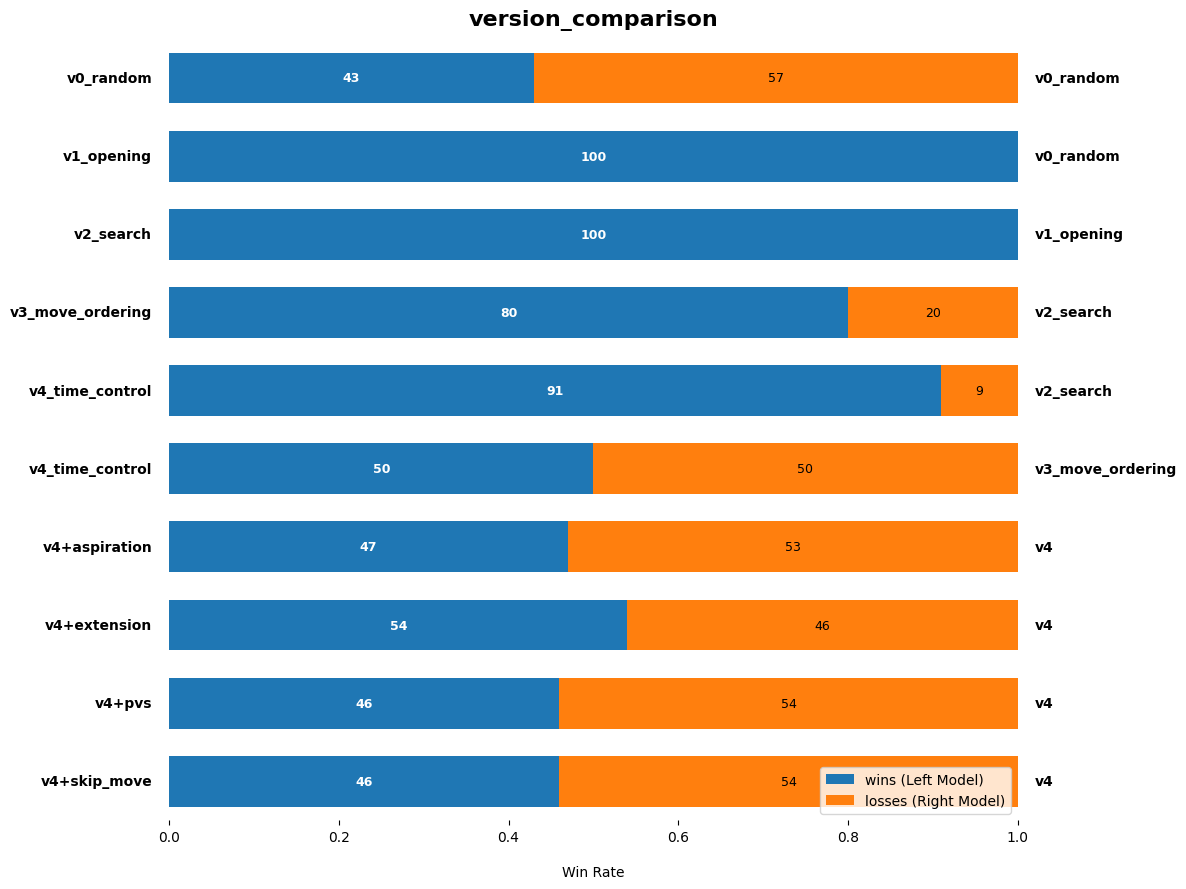

In [ ]:
configs = os.listdir('./config/exp_configs/version_comparison')
configs = [os.path.join('./config/exp_configs/version_comparison', config) for config in configs]
run_names = [get_run_name(config_path) for config_path in configs]
plot_win_rate(run_names, 'version_comparison', True)
plt.savefig('./assets/version_comparison.jpg')

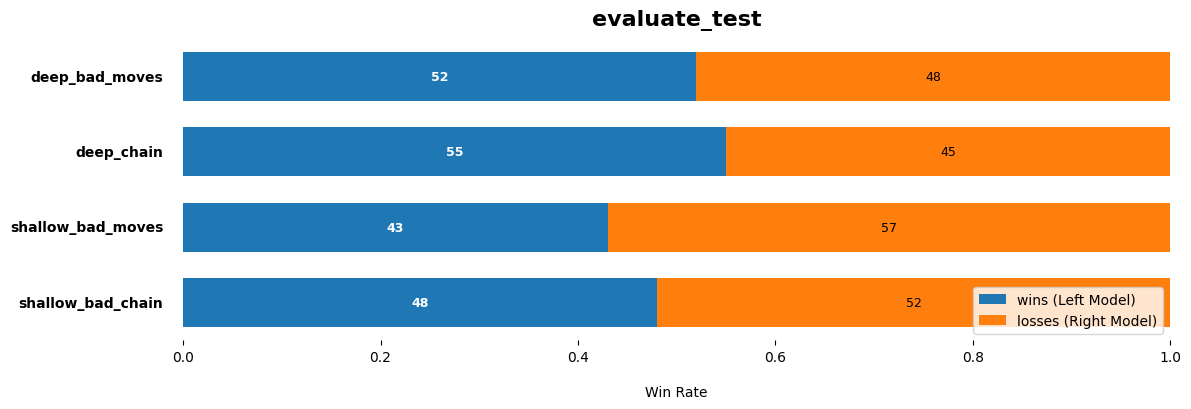

In [158]:
configs = os.listdir('./config/exp_configs/evaluate_test')
configs = [os.path.join('./config/exp_configs/evaluate_test', config) for config in configs]
run_names = [get_run_name(config_path) for config_path in configs]
plot_win_rate(run_names, 'evaluate_test', True)
plt.savefig('./assets/evaluate_test.jpg')